## How much does the average person earn?

What led me to be curious about the dataset was the different costs of living for people around the world. Every time I go back to China, I get extremely surprised at how cheap things are. For example, I can easily get a bubble tea for 9 yuan (1.31 USD) in China, but in DC it costs more than 6 USD. That is why I don't drink bubble tea in the US anymore.&#9786;

Of course, this means that income in the world is also different. Chinese prices may seem very low to me, but is probably normal for the average worker in China.

#### My data

My data was titled, **"Average Daily Income, $/person/day, inflation- & price adjusted."** It covered the average daily income of people between the years 1800 to 2100, which meant it would predict the future income too. I retrieved this data from gapminder.org.

In [2]:
import pandas as pd

income = pd.read_csv('mincpcap_cppp.csv')

income.head()

,geo,name,1800,1801,1802,1803,1804,1805,1806,1807,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
0,afg,Afghanistan,1.0208,1.0208,1.0208,1.0208,1.0208,1.0208,1.0208,1.0208,...,17.1045,17.5239,17.9534,18.3932,18.8435,19.3044,19.7761,20.2587,20.7524,21.2574
1,ago,Angola,0.6814,0.6836,0.6869,0.6903,0.6925,0.6958,0.6991,0.7024,...,21.9803,22.3552,22.7321,23.1108,23.4911,23.8730,24.2562,24.6407,25.0263,25.4129
2,alb,Albania,0.8390,0.8415,0.8439,0.8463,0.8487,0.8511,0.8536,0.8560,...,58.1668,58.6121,59.0526,59.4880,59.9185,60.3439,60.7642,61.1794,61.5895,61.9944
3,and,Andorra,1.5746,1.5773,1.5799,1.5839,1.5865,1.5891,1.5917,1.5944,...,81.3023,81.3932,81.4820,81.5690,81.6541,81.7374,81.8189,81.8986,81.9766,82.0530
4,are,UAE,1.4255,1.4298,1.4355,1.4412,1.4469,1.4512,1.4569,1.4626,...,96.5614,96.5443,96.5276,96.5113,96.4954,96.4799,96.4647,96.4499,96.4354,96.4213


Here, I cleaned and filtered my data. I only wanted to focus on the years 1900 to 2100. I thought the years from 1900 would be more accurate and useful to see future trends.

In [3]:
income = income.drop(columns=['geo'])
income = income.rename(columns={'name':'Country'})

income = income.drop(columns=[col for col in income.columns
    if col.isdigit() and 1800 <= int(col) < 1900])

## Comparing Daily Income in USA and China

First, let's take a look at how daily income differs between the USA and China. We'll also see future estimates up to the year 2100.

In [4]:
china_usa = income.loc[income['Country'].isin(['USA', 'China'])]
china_usa = china_usa.melt(id_vars=['Country'], var_name='year', value_name='income')
china_usa['year'] = china_usa['year'].astype(int)

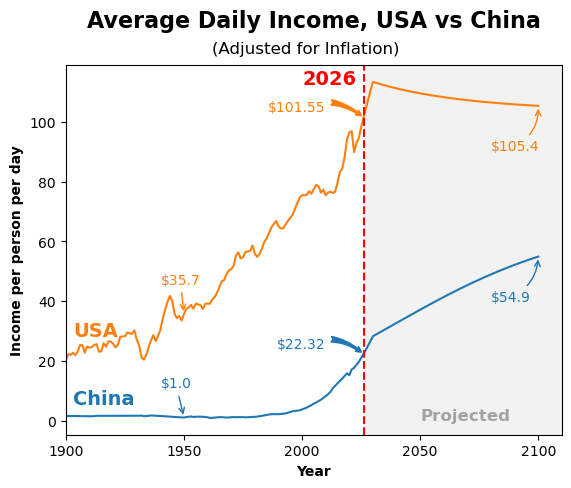

In [5]:
import matplotlib.pyplot as plt

for country in china_usa['Country'].unique():
    country_data = china_usa[china_usa['Country'] == country]
    line, = plt.plot(country_data['year'], country_data['income'])
    color = line.get_color()
    last = country_data.iloc[10]
    plt.annotate(country, xy=(last['year'], last['income']), xytext=(last['year']-7,
                last['income']+4), color=color, fontsize=14, fontweight='bold')

    row2026 = country_data[country_data['year'] == 2026]
    if not row2026.empty:
        y = row2026['income'].values[0]
        plt.annotate('$' + f"{y:.2f}", xy=(2026, y), xytext=(2015-5, y+2), ha='right',
                     arrowprops=dict(arrowstyle='fancy', color=color,
                                     connectionstyle='arc3,rad=-0.3'),
                     color=color)
    
    row1950 = country_data[country_data['year'] == 1950]
    if not row1950.empty:
        y = row1950['income'].values[0]
        plt.annotate('$' + f"{y:.1f}", xy=(1950, y), xytext=(1940, y+10),
                     arrowprops=dict(arrowstyle='->', color=color),
                     color=color)

    row2100 = country_data[country_data['year'] == 2100]
    if not row2100.empty:
        y = row2100['income'].values[0]
        plt.annotate('$' + f"{y:.1f}", xy=(2100, y), xytext=(2100 - 20, y-15),
                     arrowprops=dict(arrowstyle='->', color=color,
                                     connectionstyle='arc3,rad=0.3'),
                     color=color)

plt.axvspan(2026, 2110, color='grey', alpha=0.1)
plt.xlim(china_usa['year'].min(), 2110)
plt.xlabel('Year', fontweight='bold')
plt.ylabel('Income per person per day', fontweight='bold')
plt.xticks(range(china_usa['year'].min(), china_usa['year'].max() + 1, 50))
plt.axvline(x=2026, color='red', linestyle='--')
plt.text(2050, 0, 'Projected', 
         fontsize=12, color='grey', fontweight='bold', alpha=0.7)
plt.text(2026 -3, china_usa['income'].max() -2, '2026', va='bottom', ha='right',
         color='red', fontweight='bold', fontsize=14)
plt.title('Average Daily Income, USA vs China', fontweight='bold', fontsize=16, y=1.08)
plt.suptitle('(Adjusted for Inflation)', y=0.93)
plt.show()

We can see that the US's average daily income is steadily rising from 1900 to 2026. Luckily for us, there may be a slight decrease in year ~2030, but not by a lot. In the year 2100, the estimated daily income will be **$105.4** for the average worker.

China's average daily income starts off extremely low compared to the US, with a dollar per day. It doesn't start slightly rising until year 2000, and in year 2100 it is projected to be **$54.9**. It increased at a greater rate than the US but is still half the number of the US's daily income.

## Percentage of Change in Daily Income, 2010 vs 2026

Next, let us compare between the year 2010 and today.

In [6]:
table = income.loc[income['Country'].isin(['China', 'USA', 'Korea', 'South Korea', 
                                           Japan', 'North Korea', 'Mongolia']),
    ['Country', '2010', '2026']]

table.head()

,Country,2010,2026
32,China,8.2097,22.3200
86,Japan,48.2463,55.2757
93,South Korea,40.5840,75.4646
117,Mongolia,9.8877,18.1270
140,North Korea,3.5489,3.2557


In [7]:
table['\u0394'] = table['2026'] - table['2010']
table['% Change'] = table['\u0394'] / table['2010']

table = table.sort_values(by='% Change', ascending=True)

styled = (
    table.style
    .format({'2010':'{:,.2f}', '2026':'{:,.2f}', '\u0394':'{:+,.2f}', '% Change':'{:+.1%}'})
    .set_caption("Changes in Daily Income in 2010 and 2026")
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '24px')]},
        {'selector': 'th, td', 'props': [('border', '1px solid grey')]},
        {'selector': 'th, td', 'props': [
            ('border','1px solid black'),
            ('font-size','18px'), 
            ('text-align','center')]}])
    .background_gradient(cmap='YlGnBu', subset=['\u0394', '% Change']))

styled

,Country,2010,2026,Δ,% Change
140,North Korea,3.55,3.26,-0.29,-8.3%
86,Japan,48.25,55.28,+7.03,+14.6%
182,USA,75.46,101.55,+26.09,+34.6%
117,Mongolia,9.89,18.13,+8.24,+83.3%
93,South Korea,40.58,75.46,+34.88,+85.9%
32,China,8.21,22.32,+14.11,+171.9%


Here, we have a graph sorted in order of smallest amount of change to largest amount of change. Though China had an "average" amount of change (Δ) from 2010 to 2026, it had an enormous increase percentage-wise at **171.9%**. North Korea is the only country to see a slight negative change. Mongolia and South Korea also had noticeable amount of **increase** in change percentage.

## Income in Every East Asian Country

Next, we will compare incomes in every East Asian country, from 1950 to estimating the future income in 2100.

In [10]:
income = income.drop(columns=[col for col in income.columns
    if col.isdigit() and 1800 <= int(col) < 1950])

countries = income.loc[income['Country'].isin(['China', 'Korea', 'South Korea',
                                               'Japan', 'North Korea', 'Mongolia'])]
countries = countries.melt(id_vars=['Country'], var_name='year', value_name='income')
countries['year'] = countries['year'].astype(int)

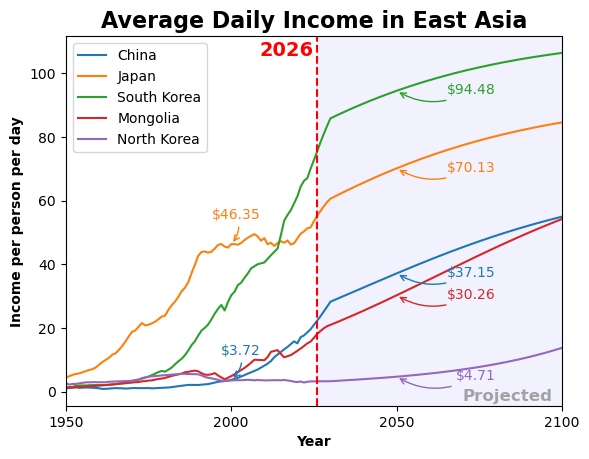

In [9]:
select = ['China', 'Japan', 'USA']

for country in countries['Country'].unique():
    country_data = countries[countries['Country'] == country]
    line, = plt.plot(country_data['year'], country_data['income'], label=country)
    color = line.get_color()

    row2050 = country_data[country_data['year'] == 2050]
    if not row2050.empty:
        y = row2050['income'].values[0]

        plt.annotate('$' + f"{y:.2f}",
                     xy=(2050, y),
                     xytext=(2080, y-1),
                     ha='right',
                     arrowprops=dict(arrowstyle='->', color=color,
                                     connectionstyle='arc3,rad=-0.3'),
                     color=color)

    if country in select:
        row2000 = country_data[country_data['year'] == 2000]
        if not row2000.empty:
            y = row2000['income'].values[0]

            plt.annotate('$' + f"{y:.2f}",
                         xy=(2000, y),
                         xytext=(2009, y+8),
                         ha='right',
                         arrowprops=dict(arrowstyle='->', color=color,
                                         connectionstyle='arc3,rad=-0.3'),
                         color=color)

plt.axvspan(2026, 2110, color='blue', alpha=0.05)
plt.xlim(countries['year'].min(), 2060)
plt.text(2070, -3, 'Projected', 
         fontsize=12, color='grey', fontweight='bold', alpha=0.7)
plt.legend()
plt.xlabel('Year', fontweight='bold')
plt.xticks(range(countries['year'].min(), countries['year'].max() + 1, 50))
plt.axvline(x=2026, color='red', linestyle='--')
plt.text(2026 -1, countries['income'].max() -2, '2026', va='bottom',
         ha='right', color='red', fontweight='bold', fontsize=14)
plt.ylabel('Income per person per day', fontweight='bold')
plt.title('Average Daily Income in East Asia', fontweight='bold', fontsize=16)
plt.show()

In this graph, we see that North Korea has stayed the same and will continue to stay the same until the year 2050. After year 2026, we can see steady increases in every country (except North Korea). **South Korea** has a particularly large jump from around three dollars per day to **$94.48** in 2050.

## Reflection

In this assignment, I analyzed the differences in average daily income in East Asian countries and the US. In the **first graph**, I compared the differences between China and the US, with the US having a much higher daily income. I did not use a legend, instead, a directly labeled USA and China with their respective colors. I added a dotted line representing 2026 in red color, so it can stand out and represent where is "today." The entire space to the right of 2026 is greyed out slightly to show that it is the future and not necessarily accurate data. I added annotations of the daily income in three locations of each country: 1950, 2026, and 2100. The arrow for 2026 is also thicker to show where we are at today.

In the **second visualization**, I made a table showing the changes in income between 2010 and 2026. I made every other row slightly grey for better readability. The color scheme for the % Change was light yellow to dark blue, and I wanted a darker color to represent high contrast. Lastly, I created black border around each box and increased font size to stand out more.

In the **third graph**, I graphed incomes of the five countries in East Asia from 1950 to 2100. Each country was represented by a different color and properly labeled in the legend. The right side of the graph, from 2026 to 2100, has a light-transparent background with a Projected label to represent the future. I also labeled 2026 in bright red exactly like the first graph. I added annotations to year 2000 and 2050, to show a stark before and after difference.

In conclusion, this assignment taught me how to add annotations and unique labels to paint a clearer picture of difference overtime in people's income. 